# Electron Density Evolution using Graph Neural Networks

This notebook explores modeling electron density evolution as a temporal graph problem.

**Goal**: Predict electron density at future timesteps given current density states.

**Approach**: 
- Treat each grid point as a node in a graph
- Model spatial relationships between grid points as edges
- Use GNNs to learn temporal evolution patterns

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.nn import GCNConv, GATConv, MessagePassing
from torch_geometric.utils import add_self_loops, degree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch version: 2.10.0+cpu
Device: cpu


## 2. Data Loading and Exploration

In [2]:
# Define data paths
ammonia_dir = Path('ammonia_x')
water_dir = Path('water_x')

def load_density_file(filepath):
    """Load a single electron density file"""
    data = np.loadtxt(filepath, usecols=1)  # Column 2 has density values
    return data

def get_all_timestep_files(directory):
    """Get all density files sorted by timestep"""
    files = sorted(glob.glob(str(directory / 'rvlab.tdscf.rho.*')))
    return files

# Load ammonia data
ammonia_files = get_all_timestep_files(ammonia_dir)
water_files = get_all_timestep_files(water_dir)

print(f"Ammonia files: {len(ammonia_files)}")
print(f"Water files: {len(water_files)}")
print(f"\nFirst few ammonia files:\n{ammonia_files[:5]}")

Ammonia files: 401
Water files: 401

First few ammonia files:
['ammonia_x/rvlab.tdscf.rho.00000', 'ammonia_x/rvlab.tdscf.rho.00005', 'ammonia_x/rvlab.tdscf.rho.00010', 'ammonia_x/rvlab.tdscf.rho.00015', 'ammonia_x/rvlab.tdscf.rho.00020']


In [3]:
# Load a sample to understand the data
sample_ammonia = load_density_file(ammonia_files[0])
sample_water = load_density_file(water_files[0])

print(f"Ammonia grid points: {len(sample_ammonia)}")
print(f"Water grid points: {len(sample_water)}")
print(f"\nAmmonia density stats:")
print(f"  Mean: {sample_ammonia.mean():.6f}")
print(f"  Std: {sample_ammonia.std():.6f}")
print(f"  Min: {sample_ammonia.min():.6f}")
print(f"  Max: {sample_ammonia.max():.6f}")
print(f"\nWater density stats:")
print(f"  Mean: {sample_water.mean():.6f}")
print(f"  Std: {sample_water.std():.6f}")
print(f"  Min: {sample_water.min():.6f}")
print(f"  Max: {sample_water.max():.6f}")

Ammonia grid points: 10540
Water grid points: 8062

Ammonia density stats:
  Mean: 10.066125
  Std: 40.032082
  Min: 0.000000
  Max: 196.639108

Water density stats:
  Mean: 19.902908
  Std: 68.776023
  Min: 0.000000
  Max: 298.349428


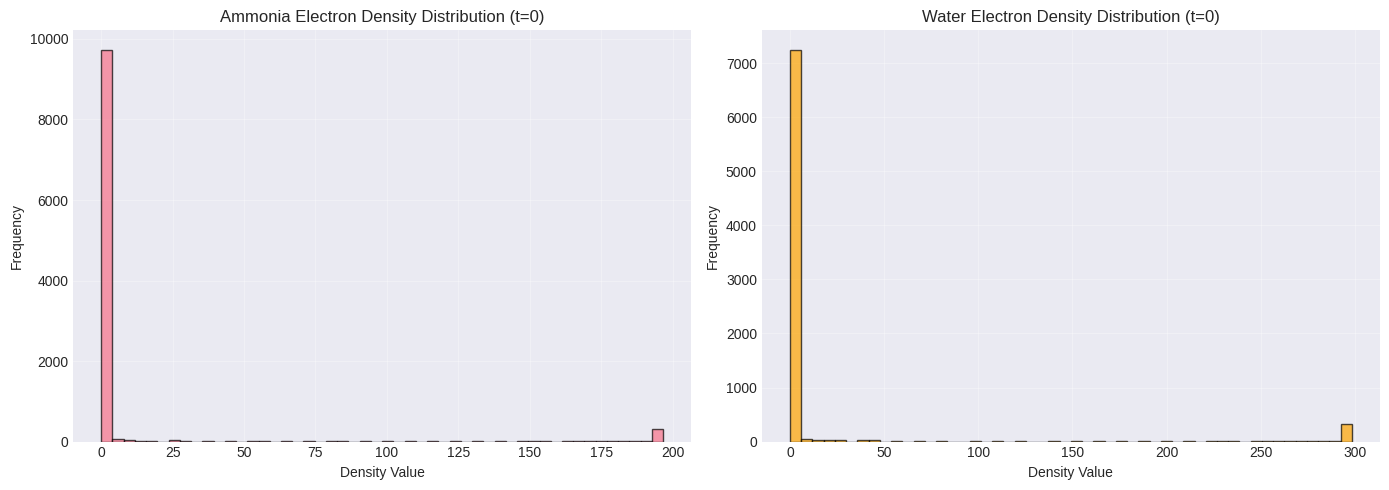

In [4]:
# Visualize density distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample_ammonia, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Ammonia Electron Density Distribution (t=0)', fontsize=12)
axes[0].set_xlabel('Density Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(sample_water, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Water Electron Density Distribution (t=0)', fontsize=12)
axes[1].set_xlabel('Density Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ammonia time series shape: (10, 10540)
Water time series shape: (10, 8062)


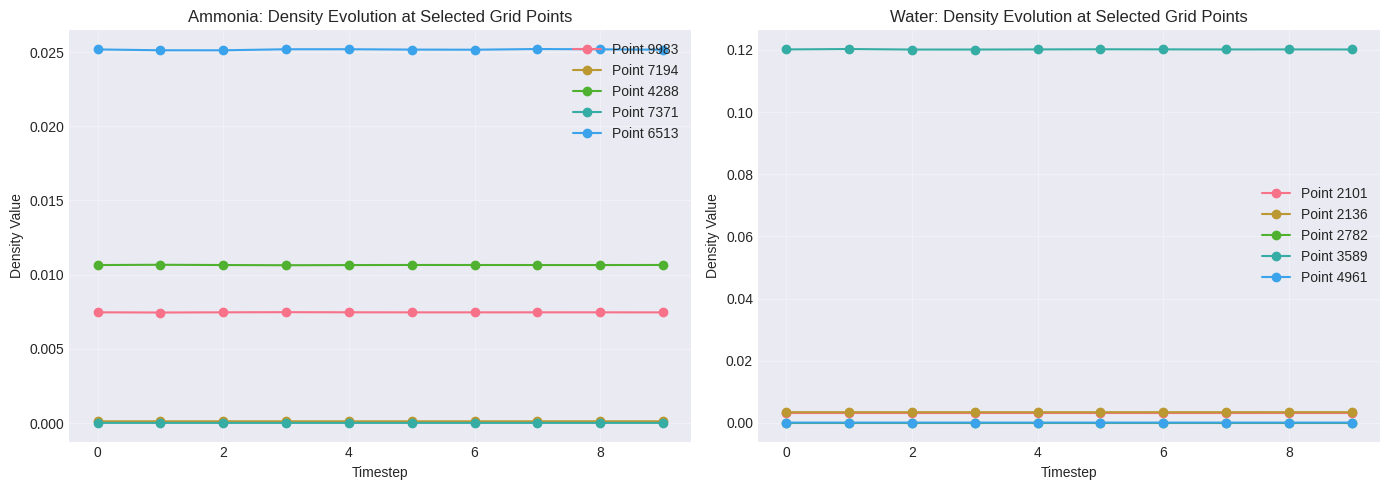

In [5]:
# Load multiple timesteps to analyze temporal evolution
n_samples = 10
ammonia_timeseries = np.array([load_density_file(f) for f in ammonia_files[:n_samples]])
water_timeseries = np.array([load_density_file(f) for f in water_files[:n_samples]])

print(f"Ammonia time series shape: {ammonia_timeseries.shape}")  # (timesteps, grid_points)
print(f"Water time series shape: {water_timeseries.shape}")

# Plot evolution of some grid points over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample 5 random grid points
sample_points = np.random.choice(len(sample_ammonia), 5, replace=False)

for i, point in enumerate(sample_points):
    axes[0].plot(ammonia_timeseries[:, point], label=f'Point {point}', marker='o')
axes[0].set_title('Ammonia: Density Evolution at Selected Grid Points', fontsize=12)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Density Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sample_points_water = np.random.choice(len(sample_water), 5, replace=False)
for i, point in enumerate(sample_points_water):
    axes[1].plot(water_timeseries[:, point], label=f'Point {point}', marker='o', color=f'C{i}')
axes[1].set_title('Water: Density Evolution at Selected Grid Points', fontsize=12)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Density Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Graph Construction

Since we don't have explicit spatial coordinates, we'll construct a graph based on:
1. **k-NN in feature space**: Connect nodes whose density values are similar
2. **Sequential neighbors**: Connect adjacent grid point indices
3. **Fully connected** (for small graphs): Connect all nodes

In [6]:
def build_sequential_edges(num_nodes, k=5):
    """
    Build edges connecting each node to its k nearest sequential neighbors
    """
    edge_index = []
    for i in range(num_nodes):
        for j in range(max(0, i-k), min(num_nodes, i+k+1)):
            if i != j:
                edge_index.append([i, j])
    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

def build_knn_edges(features, k=10):
    """
    Build edges connecting each node to its k nearest neighbors in feature space
    """
    from sklearn.neighbors import NearestNeighbors
    
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(features.reshape(-1, 1))
    distances, indices = nbrs.kneighbors(features.reshape(-1, 1))
    
    edge_index = []
    for i, neighbors in enumerate(indices):
        for j in neighbors[1:]:  # Skip first neighbor (itself)
            edge_index.append([i, j])
    
    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# Test edge construction
test_edges_seq = build_sequential_edges(len(sample_ammonia), k=5)
test_edges_knn = build_knn_edges(sample_ammonia, k=10)

print(f"Sequential edges: {test_edges_seq.shape}")
print(f"k-NN edges: {test_edges_knn.shape}")

Sequential edges: torch.Size([2, 105370])
k-NN edges: torch.Size([2, 105400])


## 4. Dataset Creation

Create a PyTorch Geometric dataset where:
- Input: Density at time t (and possibly t-1, t-2, ...)
- Output: Density at time t+Δt

In [7]:
class DensityGraphDataset(Dataset):
    """
    Dataset for electron density prediction using graphs
    """
    def __init__(self, density_files, lookback=1, lookahead=1, edge_type='sequential', k=10):
        """
        Args:
            density_files: List of file paths to density data
            lookback: Number of previous timesteps to use as input
            lookahead: Number of timesteps ahead to predict
            edge_type: 'sequential', 'knn', or 'both'
            k: Number of neighbors for edge construction
        """
        super().__init__()
        self.density_files = density_files
        self.lookback = lookback
        self.lookahead = lookahead
        self.edge_type = edge_type
        self.k = k
        
        # Load first file to determine number of nodes
        sample = load_density_file(density_files[0])
        self.num_nodes = len(sample)
        
    def len(self):
        return len(self.density_files) - self.lookback - self.lookahead + 1
    
    def get(self, idx):
        # Load input timesteps
        input_densities = []
        for i in range(idx, idx + self.lookback):
            density = load_density_file(self.density_files[i])
            input_densities.append(density)
        
        # Load target timestep
        target_density = load_density_file(self.density_files[idx + self.lookback + self.lookahead - 1])
        
        # Stack input features (num_nodes, lookback)
        x = torch.tensor(np.column_stack(input_densities), dtype=torch.float)
        y = torch.tensor(target_density, dtype=torch.float)
        
        # Build edges based on the current density
        if self.edge_type == 'sequential':
            edge_index = build_sequential_edges(self.num_nodes, k=self.k)
        elif self.edge_type == 'knn':
            edge_index = build_knn_edges(input_densities[-1], k=self.k)
        elif self.edge_type == 'both':
            edge_seq = build_sequential_edges(self.num_nodes, k=self.k)
            edge_knn = build_knn_edges(input_densities[-1], k=self.k)
            edge_index = torch.cat([edge_seq, edge_knn], dim=1)
        
        # Remove duplicate edges
        edge_index = torch.unique(edge_index, dim=1)
        
        return Data(x=x, edge_index=edge_index, y=y)

# Create datasets
print("Creating ammonia dataset...")
ammonia_dataset = DensityGraphDataset(
    ammonia_files[:100],  # Use first 100 timesteps for testing
    lookback=3,
    lookahead=5,
    edge_type='both',
    k=10
)

print(f"Dataset size: {len(ammonia_dataset)}")
print(f"\nSample data point:")
sample_data = ammonia_dataset[0]
print(f"  Input features shape: {sample_data.x.shape}")  # (num_nodes, lookback)
print(f"  Target shape: {sample_data.y.shape}")  # (num_nodes,)
print(f"  Edge index shape: {sample_data.edge_index.shape}")  # (2, num_edges)
print(f"  Number of edges: {sample_data.edge_index.shape[1]}")

Creating ammonia dataset...
Dataset size: 93

Sample data point:
  Input features shape: torch.Size([10540, 3])
  Target shape: torch.Size([10540])
  Edge index shape: torch.Size([2, 302216])
  Number of edges: 302216


## 5. GNN Model Architecture

In [8]:
class DensityGNN(nn.Module):
    """
    Graph Neural Network for electron density prediction
    """
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, dropout=0.1):
        super(DensityGNN, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # GNN layers (using GCN)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Project input features
        x = self.input_proj(x)
        x = F.relu(x)
        
        # Apply GNN layers
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < self.num_layers - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Output projection
        x = self.output_proj(x)
        
        return x.squeeze(-1)  # (num_nodes,)

# Create model
model = DensityGNN(input_dim=3, hidden_dim=128, num_layers=4, dropout=0.1)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

DensityGNN(
  (input_proj): Linear(in_features=3, out_features=128, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GCNConv(128, 128)
  )
  (output_proj): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 74,881


## 6. Training Setup

In [9]:
from torch_geometric.loader import DataLoader

# Split dataset
train_size = int(0.8 * len(ammonia_dataset))
val_size = len(ammonia_dataset) - train_size

train_dataset = [ammonia_dataset[i] for i in range(train_size)]
val_dataset = [ammonia_dataset[i] for i in range(train_size, len(ammonia_dataset))]

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Training configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

print(f"\nTraining on device: {device}")

Train samples: 74
Validation samples: 19

Training on device: cpu


In [10]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)
        loss = criterion(out, batch.y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(loader.dataset)

# Training loop
num_epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...\n")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_density_gnn.pt')
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

print(f"\nBest validation loss: {best_val_loss:.6f}")

Starting training...

Epoch   5 | Train Loss: 19.729800 | Val Loss: 3.138841 | LR: 0.001000
Epoch  10 | Train Loss: 15.505488 | Val Loss: 2.677605 | LR: 0.001000
Epoch  15 | Train Loss: 14.015431 | Val Loss: 2.789394 | LR: 0.001000
Epoch  20 | Train Loss: 12.600781 | Val Loss: 2.724026 | LR: 0.001000
Epoch  25 | Train Loss: 11.630069 | Val Loss: 2.678910 | LR: 0.001000
Epoch  30 | Train Loss: 11.559834 | Val Loss: 3.086705 | LR: 0.001000
Epoch  35 | Train Loss: 11.589316 | Val Loss: 2.960721 | LR: 0.001000
Epoch  40 | Train Loss: 11.441571 | Val Loss: 2.666448 | LR: 0.000500
Epoch  45 | Train Loss: 11.567513 | Val Loss: 3.055928 | LR: 0.000500
Epoch  50 | Train Loss: 11.475674 | Val Loss: 2.828670 | LR: 0.000500

Best validation loss: 2.665022


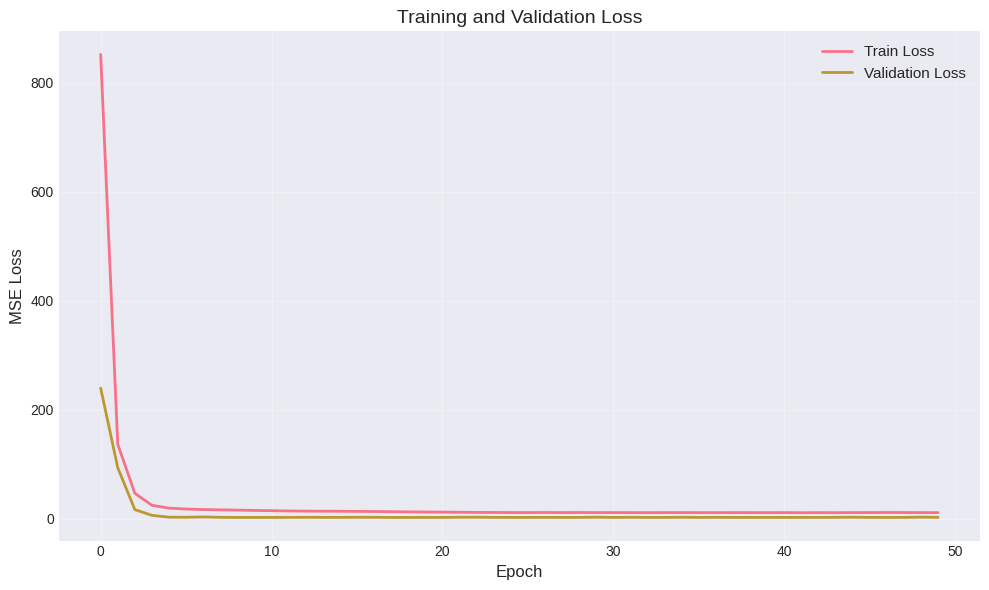

In [11]:
# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Evaluation and Visualization

In [12]:
# Load best model
model.load_state_dict(torch.load('best_density_gnn.pt'))
model.eval()

# Make predictions on validation set
predictions = []
targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch)
        predictions.append(out.cpu().numpy())
        targets.append(batch.y.cpu().numpy())

predictions = np.concatenate(predictions)
targets = np.concatenate(targets)

# Calculate metrics
mse = np.mean((predictions - targets) ** 2)
mae = np.mean(np.abs(predictions - targets))
r2 = 1 - np.sum((targets - predictions) ** 2) / np.sum((targets - targets.mean()) ** 2)

print(f"Validation Metrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  R²: {r2:.6f}")

Validation Metrics:
  MSE: 2.665022
  MAE: 0.286683
  R²: 0.998337


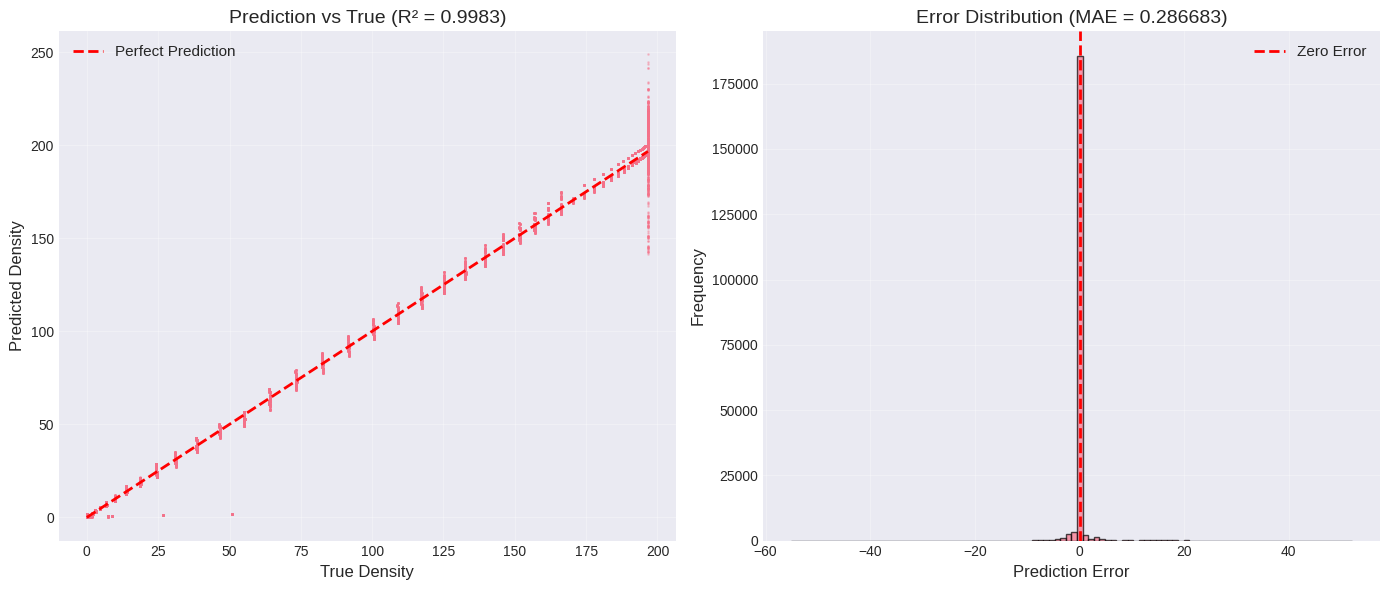

In [13]:
# Prediction vs Target scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(targets, predictions, alpha=0.3, s=1)
axes[0].plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True Density', fontsize=12)
axes[0].set_ylabel('Predicted Density', fontsize=12)
axes[0].set_title(f'Prediction vs True (R² = {r2:.4f})', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = predictions - targets
axes[1].hist(errors, bins=100, alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='r', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Error Distribution (MAE = {mae:.6f})', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Future Work and Improvements

**Model Improvements:**
1. Try Graph Attention Networks (GAT) for better edge weighting
2. Implement temporal convolutions or RNN/LSTM layers
3. Multi-task learning: predict multiple future timesteps
4. Add residual connections for deeper networks

**Data Enhancements:**
1. Incorporate actual 3D grid coordinates if available
2. Use both ammonia and water for transfer learning
3. Data augmentation techniques
4. Normalize/standardize features

**Graph Construction:**
1. Learn edge weights dynamically
2. Use attention mechanisms to determine connectivity
3. Experiment with different neighborhood sizes
4. Build multi-scale graphs (coarse and fine)

**Evaluation:**
1. Long-term prediction accuracy (autoregressive prediction)
2. Physical constraint validation
3. Domain-specific metrics for quantum chemistry